In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# 1. Загружаем датасет
housing = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = housing.frame

# 2. Отбираем сбалансированный набор колонок под наши задачи
cols = [
    'LotFrontage',   # Расстояние до улицы (есть пропуски, числовой)
    'GrLivArea',     # Жилая площадь (числовой, есть выбросы)
    'OverallQual',   # Качество дома от 1 до 10 (числовой, ограниченный)
    'ExterQual',     # Качество экстерьера (Ex, Gd, TA, Fa, Po) — Ordinal
    'CentralAir',    # Кондиционер ('Y', 'N') — Binary Nominal
    'Neighborhood', # Район (25 категорий, High Cardinality) — Nominal
    'SalePrice'      # Наш ТАРГЕТ (y)
]

data = df[cols].copy()


In [5]:
# 1
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1168, 6) (292, 6)


In [6]:
# 2
median_lf = X_train['LotFrontage'].median()
print(median_lf)
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(median_lf)

X_test['LotFrontage'] = X_test['LotFrontage'].fillna(median_lf)


70.0


,LotFrontage,GrLivArea,OverallQual,ExterQual,CentralAir,Neighborhood,scaled_OverallQual,scaled_LotFrontage,scaled_GrLivArea
254,70.0,1314,5,TA,Y,NAmes,0.444444,0.000000,-0.246035
1066,59.0,1571,6,Gd,Y,Gilbert,0.555556,-0.578947,0.151644
638,67.0,796,5,TA,Y,Edwards,0.444444,-0.157895,-1.047582
799,60.0,1768,5,TA,Y,SWISU,0.444444,-0.526316,0.456480
380,50.0,1691,5,TA,Y,SWISU,0.444444,-1.052632,0.337331


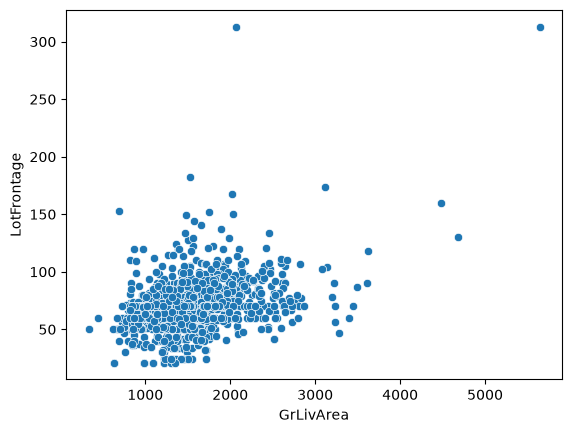

In [7]:
# 3
from sklearn.preprocessing import MinMaxScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaler = MinMaxScaler()
X_train['scaled_OverallQual'] = scaler.fit_transform(X_train[['OverallQual']])

X_test['scaled_OverallQual'] = scaler.transform(X_test[['OverallQual']])

sns.scatterplot(data=X_train, x='GrLivArea', y='LotFrontage')

rob_scaler = RobustScaler()

X_train['scaled_LotFrontage'] = rob_scaler.fit_transform(X_train[['LotFrontage']])
X_test['scaled_LotFrontage'] = rob_scaler.transform(X_test[['LotFrontage']])

X_train['scaled_GrLivArea'] = rob_scaler.fit_transform(X_train[['GrLivArea']])
X_test['scaled_GrLivArea'] = rob_scaler.transform(X_test[['GrLivArea']])
X_train.head()


In [ ]:
# 4
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

encoder = OrdinalEncoder(categories=[['Po', 'Fa', 'TA', 'Gd', 'Ex']])
X_train['ExterQual_encoded'] = encoder.fit_transform(X_train[['ExterQual']])
X_test['ExterQual_encoded'] = encoder.transform(X_test[['ExterQual']])

encoder_ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train['CentralAir_encoded'] = encoder_ohe.fit_transform(X_train[['CentralAir']])
X_test['CentralAir_encoded'] = encoder_ohe.transform(X_test[['CentralAir']])

In [23]:
# 5 
global_y = y_train.mean()

train_data = pd.DataFrame({
    'Neighbourhood' : X_train['Neighborhood'],
    'target' : y_train
})

stats = train_data.groupby('Neighbourhood')['target'].agg(['count', 'mean'])
stats.columns = ['n_i', 'y_i_mean']

m = 10
alfa = stats['n_i'] / (stats['n_i'] + m)
stats['S_i'] = alfa * stats['y_i_mean'] + (1 - alfa) * global_y
encoding_map = stats['S_i'].to_dict()
stats.head()

X_train['Neighborhood'] = X_train['Neighborhood'].map(encoding_map)
X_test['Neighborhood'] = X_test['Neighborhood'].map(encoding_map).fillna(global_y)
X_test.head()


,LotFrontage,GrLivArea,OverallQual,ExterQual,CentralAir,Neighborhood,scaled_OverallQual,scaled_LotFrontage,scaled_GrLivArea,ExterQual_encoded,CentralAir_encoded
892,70.0,1068,6,TA,Y,143422.770875,0.555556,0.000000,-0.626692,2.0,1.0
1105,98.0,2622,8,Gd,Y,290221.474873,0.777778,1.473684,1.777950,3.0,1.0
413,56.0,1028,5,TA,Y,137694.291282,0.444444,-0.736842,-0.688588,2.0,1.0
522,50.0,1664,6,TA,Y,133331.189446,0.555556,-1.052632,0.295551,2.0,1.0
1036,89.0,1620,9,Gd,Y,221746.800514,0.888889,1.000000,0.227466,3.0,1.0
